In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))


**<font size="6" color="red">ch2. 한글형태소 분석 및 시각화</font>**
# 1. 자연어처리
- 자연어 : 사람이 사용하는 일상적인 언어
- 자연어 처리 분야
    * 탐색(이해) : 형태소 분석 -> pos tagging(품사태깅) -> 의미분석 또는 시각화
    * 모델 생성 : RNN, LSTM, GRU, seq2seq, transformer
    
# 2. 자연어 처리 절차
- 분석 후보 생성 : 형태소 분리, 품사태깅
- 제약조건 : 규칙 확인 및 불용어 처리
- 분석 : 시각화(워드클라우드, plot), 유사도 분석, 연관분석, RNN, LSTM, GRU, seq2seq, transformer

# 3. 한글 형태소 분석 엔진(Konlpy, ...)
    - 공통기능 : morphs(형태소 나누기), pos(형사태로 나누어 품사태그), nouns(명사추출)

- Konlpy (pip install Konlpy) : Konlpy.org -> API -> POS tagging with KoNLPy -> Korean POS tags comparison chart
    * HanNanum : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * Kkma : "
    * Komoran : "
    * Okt 
- Mecab(pip install python-mecab-ko)
    * MeCab : c++로 만든 형태소 분석기. 저사양환경에서 사용가능. 다국어바인딩 지원
- Konlp : R용 자연어 처리기

In [2]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [3]:
import konlpy
konlpy.__version__

'0.6.0'

## 3.1 HanNanum

In [ ]:
text = '''
아름답지만 다소 복잡한 한국어는 
전세계에서 13번째로 많이 사용되는 언어입니다
'''

In [5]:
from konlpy.tag import Hannanum
hannanum = Hannanum(
    jvmpath=None, 
    max_heap_size=512   # 기본값 : 1024M,  '1024m', '1g', 최대사이즈 4g
)
hannanum.analyze(text) # text를 세밀하게 분석해서, 형태소, 품사를 반환(ntag=69로 형태소 분석)

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('한', 'ncn')],
  [('복잡', 'ncps'), ('한', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]]]

- Korean POS tags comparison chart.xlsx (다운로드)

In [6]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [7]:
# 명사만 추출 : nouns
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [8]:
# 품사 태깅 : pos
print(hannanum.pos(text, ntags=22))

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF')]


In [9]:
# ex1. text에서 형용사(PA)만 추출
tagged_text = hannanum.pos(text, ntags=22)
# words = []
# for token, tag in tagged_text:
#    print(token, tag)
#    if tag == 'PA':
#        words.append(token)
words = [token for token, tag in tagged_text if tag=='PA']
print(words)

['아름답', '많']


In [10]:
# ex2. text에서 명사(NC, NQ, NP, NN)만 추출
tags = ['NC', 'NQ', 'NP', 'NN']
words = [token for token, tag in tagged_text if tag in tags]
words

['복잡', '한국어', '전세계', '13', '사용', '언어']

In [11]:
# ex3. text에서 보통명사(NC)만 추출
tags = ['NC']
words = [token for token, tag in tagged_text if tag in tags]
words

['복잡', '한국어', '전세계', '사용', '언어']

## 3.2 Kkma

In [ ]:
from konlpy.tag import Kkma
# kkma = Kkma(jvmpath=None, max_heap_size=1024)
kkma = Kkma()
# 형태소 분석
print(kkma.morphs(text))

In [ ]:
# 품사 태깅
print(kkma.pos(text)) # ntags 지정 불가 (무조건 56으로)

In [ ]:
# 품사태깅을 이용한 명사(NNG, NNP, NP) 추출
tagged_text = kkma.pos(text)
words = [token for token, tag in tagged_text if tag in ('NNG', 'NNP', 'NP')]
print(words)

In [ ]:
# nouns함수를 이용한 명사 추출
print(kkma.nouns(text))

## 3.3 Komoran

In [6]:
text = '''
아름답지만 다소 복잡한 한국어는 
전세계에서 13번째로 많이 사용되는 언어입니다
'''

In [7]:
from konlpy.tag import Komoran
komoran = Komoran()
# 형태소 분석
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', 'ㄴ', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [9]:
# 명사 추출
print(komoran.nouns(text))

['한국어', '전', '세계', '번', '사용', '언어']


In [10]:
# 품사태깅(pos tagging)
tagged_list = komoran.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('ㄴ', 'ETM'), ('한국어', 'NNP'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNB'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EC')]


In [11]:
# 일반명사(NNG) + 고유명사(NNP) 추출 
print([token for token, tag in tagged_list if  tag in ('NNG', 'NNP')])

['한국어', '전', '세계', '사용', '언어']


## 3.4 Okt(Twitter)
- konlpy v0.4.5부터 Twitter -> Okt로 바뀜
- SNS 텍스트 분석용 개발
- Scala로 개발 - (컴파일) -> .class파일 (JVM위에서 실행)

In [15]:
from konlpy.tag import Twitter, Okt
# okt = Twitter()
okt = Okt()
print('명사구 추출 :', okt.phrases(text))
# 형태소 분석
print('형태소 분석 :', okt.morphs(text))

명사구 추출 : ['다소', '다소 복잡한 한국어', '전세계', '13번째', '사용', '사용되는 언어', '한국어', '13', '번째', '언어']
형태소 분석 : ['\n', '아름답지만', '다소', '복잡한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '많이', '사용', '되는', '언어', '입니다', '\n']


In [17]:
# 명사만 추출
print(okt.nouns(text))

['다소', '한국어', '전세계', '번', '사용', '언어']


In [18]:
# 품사태깅
tagged_list = okt.pos(text)
print(tagged_list)

[('\n', 'Foreign'), ('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡한', 'Adjective'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('\n', 'Foreign')]


In [21]:
# 명사(Noun)만 추출
print([word for word, tag in tagged_list if tag == 'Noun'])

['다소', '한국어', '전세계', '번', '사용', '언어']


## 3.5 MeCab
- pip install python-mecab-ko
- 압도적 속도(Konlpy 대비 5~20배 빠름)
- 낮은 메모리 사용량
- 형태소 분해 정확도 높음. 네이버, 카카오, 라인 등에서도 mecab 계열을 사용한 사례 많음

In [22]:
# 형태소 분석
from mecab import MeCab
mecab = MeCab()
print(mecab.morphs(text))

['아름답', '지만', '다소', '복잡', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다']


In [23]:
# 명사 추출
print(mecab.nouns(text))

['한국어', '세계', '번', '사용', '언어']


In [24]:
# 품사태깅
tagged_list = mecab.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('한', 'XSA+ETM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EC')]


In [26]:
# 명사들(NNG, NNP, NP, NR) 추출
print([token for token, tag in tagged_list if tag in ('NNG', 'NNP', 'NP', 'NR')])

['한국어', '세계', '사용', '언어']


# 4. 말뭉치(Corpus)

In [4]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw("austen-emma.txt")
print(emma[:30])

[Emma by Jane Austen 1816]

VO


In [5]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\mbc1\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [6]:
# 한국어 말뭉치
from konlpy.corpus import kolaw
kolaw_data = kolaw.open('constitution.txt').read()
print('글자수 :', len(kolaw_data))
print('%r' % kolaw_data[:50])

글자수 : 18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임'


# 5. 워드 클라우드
- pip install wordcloud
- pip install gensim : 워드임베딩(단어간 거리 계산)

In [7]:
nouns = ['word1', 'word2', 'word1']

''.join(nouns)

'word1word2word1'

In [8]:
# 영어 말뭉치에서 2글자 이상의 단어 추출(특수문자 제외)하여 워드클라우드 생성
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
ret = RegexpTokenizer('[a-zA-Z0-9]{2,}')
words = ret.tokenize(emma)
emma_tags = pos_tag(words)

# 명사 추출(NN, NNS, NNP, NNPS)
noun_list = [token for token, tag in emma_tags if tag in ('NN', 'NNS', 'NNP', 'NNPS')]
print('추출된 명사 개수 :', len(noun_list), ', 단어 종류수:', len(set(noun_list)))
emma_noun = ' '.join(noun_list)
print('워드 클라우드에서 필요한 text :', emma_noun[:200])

추출된 명사 개수 : 32488 , 단어 종류수: 4012
워드 클라우드에서 필요한 text : Emma Jane Austen VOLUME CHAPTER Emma Woodhouse clever home disposition blessings existence years world daughters indulgent father consequence marriage mistress house period mother remembrance caresses


In [12]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize']  = [10, 5] # 기본값 [6.4, 4.8]

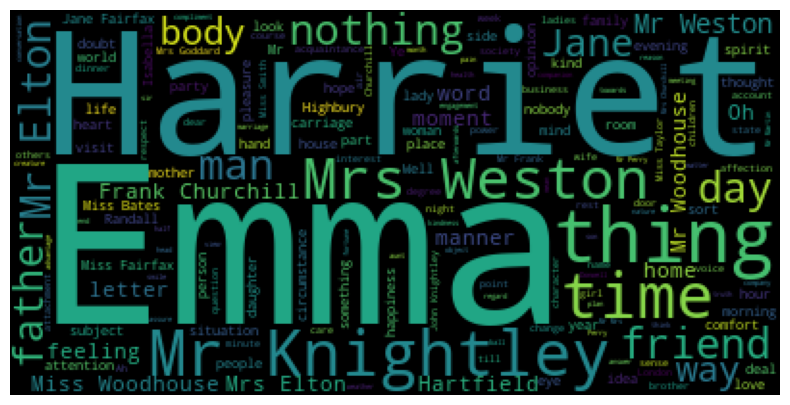

In [14]:
wordcloud = WordCloud()
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

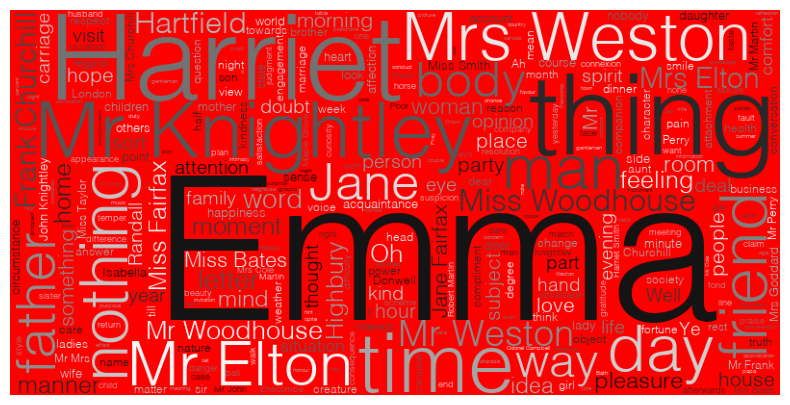

In [28]:
wordcloud = WordCloud(font_path=r'C:\USERS\MBC1\APPDATA\LOCAL\MICROSOFT\WINDOWS\FONTS\HELVETICA LIGHT.TTF', # 글자 폰트
                      width=800, # 생성될 이미지 가로(픽셀) 기본값은 400
                      height=400, # 생성될 이미지 세로(픽셀) 기본값은 200
                      background_color='red', # 배경색
                      max_words=300, # 표시될 단어의 최대 개수
                      relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                      colormap='Greys', # 글씨 색상들(컬러맵)
#                       max_font_size=80, # 폰트 최대 크기 조절(픽셀)
#                       min_font_size=10 # 폰트 최소 크기 조절
                     )
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [29]:
# 생성된 wordcloud 저장
wordcloud.to_file('emma.jpg') # jpg나 png

In [35]:
# 한글 말뭉치 kolaw_data
kolaw_data[:10]
from mecab import MeCab
from nltk import FreqDist
import pandas as pd
analyzer = MeCab()

noun_list = analyzer.nouns(kolaw_data)
noun_list = [word for word, tag in analyzer.pos(kolaw_data) if tag in ('NNG', 'NNP')]
noun_wordcount = FreqDist(noun_list)
noun_wordcount

wordCnt = pd.Series(noun_wordcount)
wordCnt.sort_values(ascending=False, inplace=True)
wordCnt.head(10) 

법률     121
대통령     84
조       79
국가      73
헌법      69
국민      69
국회      69
때       55
필요      31
위원      30
dtype: int64

In [36]:
# 워드 클라우드에서 필요한 text
data_noun = ' '.join(noun_list)
data_noun[:100]

'대한민국 헌법 역사 전통 국민 운동 건립 대한민국 임시 정부 법통 불의 항거 민주 이념 계승 조국 민주 개혁 평화 통일 사명 입각 정의 인도 동포 애 민족 단결 사회 폐습 불의 타'

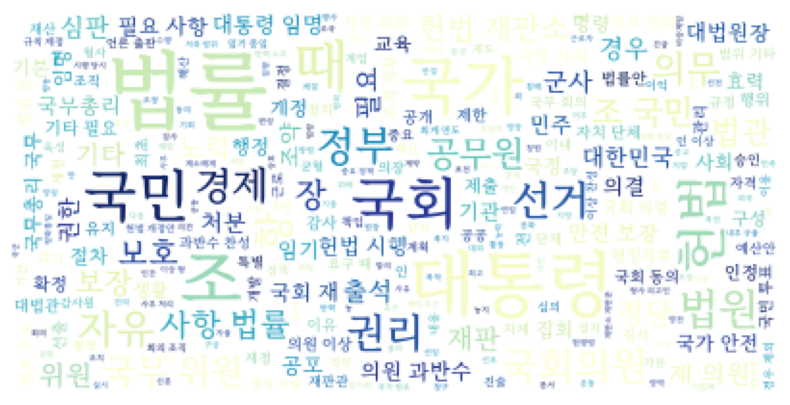

In [43]:
wordcloud = WordCloud(
    font_path=r'C:\USERS\MBC1\APPDATA\LOCAL\MICROSOFT\WINDOWS\FONTS\MARUBURI-SEMIBOLD.TTF',
    background_color='white', # 배경색
    max_words=300, # 표시될 최대 단어 수
    colormap='YlGnBu',
    # random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [45]:
# 불용어 처리
from wordcloud import STOPWORDS # 영어권 등록된 불용어
from nltk.corpus import stopwords
print('라이브러리에 등록된 불용어 언어들 :', stopwords.fileids() )
불용어 = {'조', '대통령', '법률'}
print(불용어)

라이브러리에 등록된 불용어 언어들 : ['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'tamil', 'turkish', 'uzbek']
{'대통령', '법률', '조'}


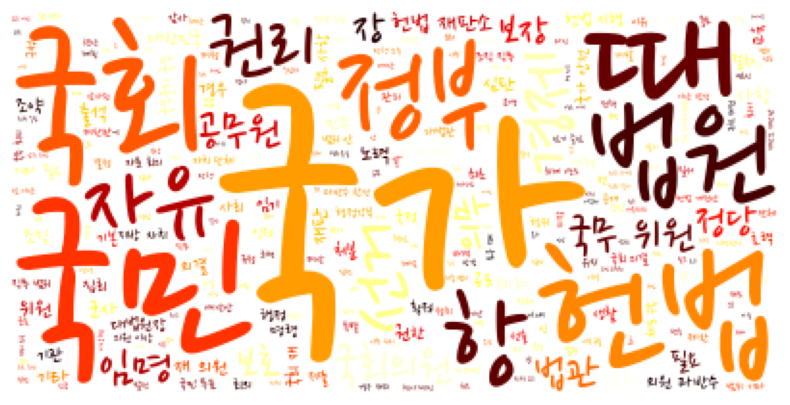

In [48]:
wordcloud = WordCloud(
    font_path=r'C:/USERS/MBC1/APPDATA/LOCAL/MICROSOFT/WINDOWS/FONTS/NanumPenScript-Regular.ttf',
    background_color='white', # 배경색
    max_words=300, # 표시될 최대 단어 수
    colormap='hot',
    stopwords=불용어,
    # random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

TypeError: Image data of dtype object cannot be converted to float

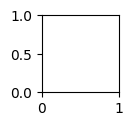

In [82]:
# 워드클라우드의 mask가 될 이미지 -> numpy 배열
# 이미지를 넘파이 배열로 방법1
import cv2
mask = cv2.imread(r'C:\ai\lecNote\06_자연어처리\data\test3.png')
plt.figure(figsize=(1,1))
plt.imshow(mask)
print(mask.shape, type(mask))

In [79]:
# 이미지를 넘파이 배열로 방법2
from PIL import Image
import numpy as np
img = Image.open('data/heart.jpg')
mask = np.array(img)
plt.figure(figsize=(1,1))
plt.imshow(mask, cmap='gray')
print(type(img), type(mask), mask.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/heart.jpg'

In [76]:
# mask2 = cv2.imread('data/test2.jpg')
# plt.figure(figsize=(3,3))
# plt.imshow(mask2)
# mask2.shape
img = Image.open('data/test2.jpg')
mask2 = np.array(img) # 255흰색, 0:검정색 (uint8)
plt.figure(figsize=(3,3))
mask2 = np.where(mask2>200, 255, 0).astype(np.uint8)
plt.imshow(mask2)
mask2.shape, mask2.dtype

FileNotFoundError: [Errno 2] No such file or directory: 'data/test2.jpg'

In [77]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white', # 배경색
                max_words=300, #표시될 최대 단어 수
                colormap='viridis',
                stopwords=불용어,
                mask=mask2
                # random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

NameError: name 'mask2' is not defined

In [ ]:
# mask2 = cv2.imread('data/test2.jpg')
# plt.figure(figsize=(3,3))
# plt.imshow(mask2)
# mask2.shape
# 1채널 이미지 -> 3채널 변환
img = Image.open('data/south_korea.png').convert('RGB')
mask2 = np.array(img) # 255흰색, 0:검정색 (uint8)
plt.figure(figsize=(3,3))
plt.imshow(mask2)
mask2.shape, mask2.dtype

In [ ]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white', # 배경색
                max_words=300, #표시될 최대 단어 수
                colormap='viridis',
                stopwords=불용어,
                mask=mask2,
                contour_width=1,
                contour_color='blue'
                # random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

## 단어의 빈도수 시각화

In [89]:
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize']=(20,4)

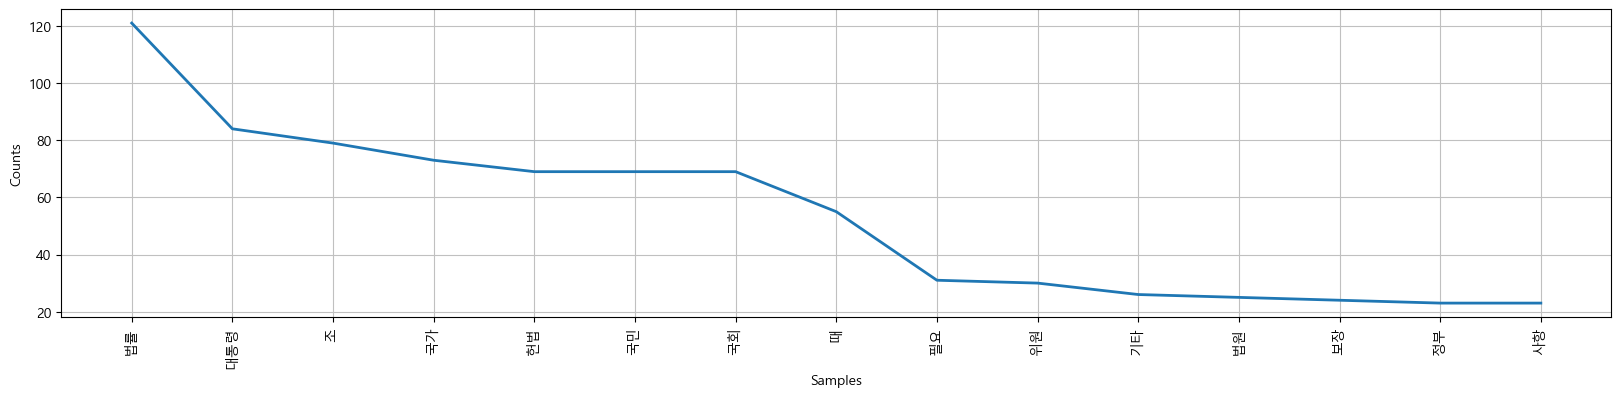

<Axes: xlabel='Samples', ylabel='Counts'>

In [90]:
from nltk import Text
data_text = Text(noun_list)
data_text.plot(15)

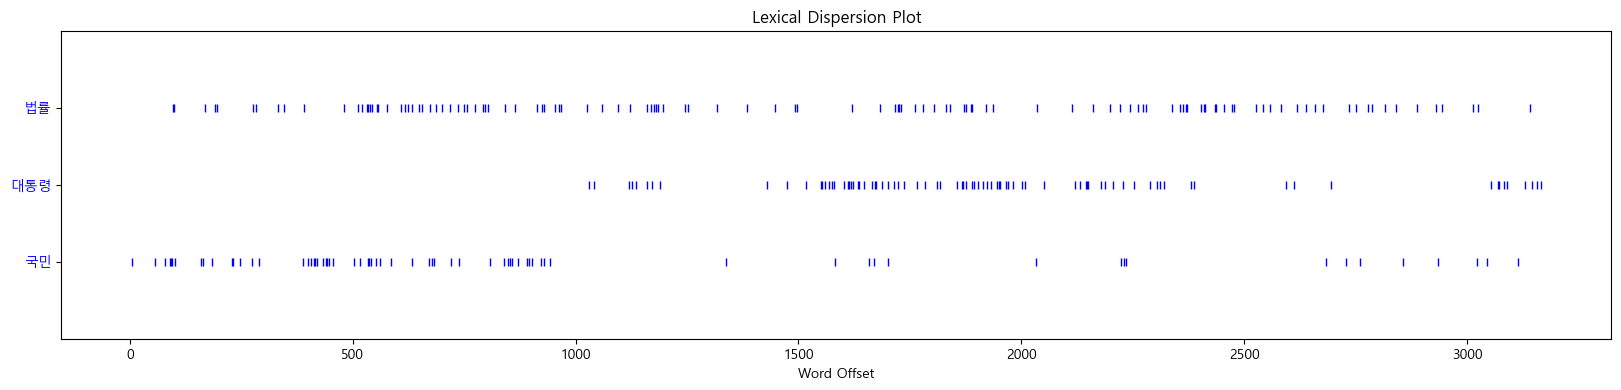

In [91]:
data_text.dispersion_plot( ['법률', '대통령', '국민'] )

# 6. 워드 임베딩
- 단어간 벡터 계산
- Word2vec은 주변에 같이 나오는 단어를 의미가 유사한 아이디어로 단어를 숫자 좌표로 바꿔서 계산

- 경제뉴스 20개를 각각 명사만 가져와서 list
    ```
    [['단어1', '단어2', '단어3',...],
     ['단어4', 단어5', '단어6', ...],
     ['단어2', '단어7', '단어1',...]...]
    ```

In [93]:
# .env 가져오기(방법1) - 강추
from dotenv import load_dotenv
import os
load_dotenv()
# print(os.getenv('CLIENT_ID'))
# print(os.getenv('CLIENT_SECRET'))

True

In [94]:
# .env가져오기(방법2) - 주피터 환경에서 안될 수 있음
from decouple import config
# print(config('CLIENT_ID'))
# print(config('CLIENT_SECRET'))

ModuleNotFoundError: No module named 'decouple'

In [97]:
# 방법 1 예시
import json
import os
import sys
import requests
import pandas as pd
from dotenv import load_dotenv
from requests import get
load_dotenv() # 환경 변수 load
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

url = f"https://openapi.naver.com/v1/search/news.json" # JSON 결과
params = {'query': '경제', 'display':20, 'sort':'date' } # 'display' : 20  = 가져올 데이터 개수  / 'sort':'date' = 최신순 뉴스
headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}
response = requests.get(url, params=params, headers=headers)

items = response.json()['items']# response를 json형태로 변환한것 중 'items' /  방법 1만 가능

# 제목(title) + ' ' + 요약(description) 텍스만 추출하여 list
news_texts = []
for item in items:
    title = item.get('title').replace('<b>', ' ').replace('</b>', ' ')
    description = item.get('description').replace('<b>', ' ').replace('</b>', ' ')
    news_texts.append(title + ' ' + description)
news_texts[:3], len(news_texts)

['폭스바겐코리아, 사고수리 품질보장 도입…출고 후 2년 보장  경제 적 부담을 낮추기 위한 지원도 마련했다. 사고수리 비용이 300만원 이상인 고객에게는 1년간 자기부담금 지원 프로그램을 제공한다. 전기차는 별도의 안전 점검이 이뤄진다. 수리 견적이 200만원을 넘는 전기차가... ',
 '[카드뉴스로 읽는 오늘의 운세] 9월 4일(금요일) 춘강 구박사가 알려주... 54년생 가정  경제 가 회복될 것이라. 66년생 지금은 너무 서두르면 손해니 천천히 행하라. 78년생 큰 염려 말라, 느긋해 지라, 담대해 지라. 90년생 마음대로 해도 이루게 되리라. 02년생 이성으로 인한 경사가 있으리라.... ',
 '경북도의회, 석면 제거·원전 감시체계 촉구…경북농협은 수해복구 ‘구... ◇연규식 도의원 “지역아동센터 석면 제거 서둘러야&quot;…긴급 예산 편성 촉구 경북=에너지 경제 신문 정재우... ◇김재준 도의원 “원전 절반 몰린 경북, 자체 안전감시 체계 갖춰야&quot; 경북=에너지 경제 신문 정재우 기자... ']

In [100]:
# 명사추출(news_texts)
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab
analyzer = MeCab()
news = []
for article in news_texts:
    noun_list = analyzer.nouns(article)
    noun_list = [word for word, tag in analyzer.pos(article) if tag in ('NNG','NNP')]
    news.append(noun_list)
print(news[:3])

[['폭스바겐', '코리아', '사고', '수리', '품질', '보장', '도입', '출고', '후', '보장', '경제', '부담', '지원', '마련', '사고', '수리', '비용', '이상', '고객', '간', '부담금', '지원', '프로그램', '제공', '전기차', '별도', '안전', '점검', '수리', '견적', '전기차'], ['카드', '뉴스', '오늘', '운세', '금요일', '춘강', '박사', '가정', '경제', '회복', '손해', '염려', '담대', '이성', '경사'], ['경북', '의회', '석면', '제거', '원전', '감시', '체계', '촉구', '경북', '농협', '수해', '복구', '규식', '도', '의원', '지역', '아동', '센터', '석면', '제거', '긴급', '예산', '편성', '촉구', '경북', '에너지', '경제', '신문', '정재우', '김재준', '도', '의원', '원전', '절반', '경북', '자체', '안전', '감시', '체계', '경북', '에너지', '경제', '신문', '정재우', '기자']]


In [101]:
print([len(nouns) for nouns in news])

[31, 15, 45, 33, 29, 32, 30, 35, 24, 26, 37, 41, 29, 31, 35, 36, 25, 29, 23, 40]


In [ ]:
# 워드 임베일(단어간 거리 계산)
from gensim.models import Word2Vec
model =Word2Vec(news, # 2차원 학습데이터
               window=15, # 각 단어의 좌우 15개 단어를 학습 컨텐츠로 사용
               min_count=2, # 2회 이상 등장한 단어만 학습
               workers=-1, # 병렬처리 core 개수 (-1:모든 가용 core 다 사용)
               sg=1 # 소량 데이터에서의 학습방식 / 대량 데이터에서는 0
               )

In [ ]:
# 학습한 단어 리스트
print(model.wv.index_to_key)

In [ ]:
# 유사도가 가장 높은 단어(거리가 가까운 단어) 10개(topn)
model.wv.most_similar('미국', topn=10) 

In [ ]:
model.wv.most_similar('추석', topn=10) 

In [ ]:
# 단어를 입력받아 유사한 단어 5개 출력하기
word = input('유사도를 알고 싶은 단어는?')
if word in model.wv:
    print(model.wv.most_similar(word, topn=5))
else:
    print(f'{word} 단어가 훈련 데이터에 없습니다')